# Basic DeepStorm Components

### Modules import and os Settings

In [ ]:
import sys
import tensorflow as tf
from tensorflow import keras
from keras.models import Model
from keras.layers import Input, Activation, UpSampling2D, Convolution2D, MaxPooling2D, BatchNormalization, Layer
from keras.callbacks import Callback
from keras import backend as K
from keras import optimizers, losses
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint
from keras.callbacks import ReduceLROnPlateau
from skimage.transform import warp
from skimage.transform import SimilarityTransform
from skimage.metrics import structural_similarity
from skimage.metrics import peak_signal_noise_ratio as psnr
from scipy.signal import fftconvolve

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
import scipy.io as sio
from os.path import abspath
from sklearn.model_selection import train_test_split
from skimage import io
import time
import os
import shutil
import csv
from PIL import Image
from PIL.TiffTags import TAGS
from scipy.ndimage import gaussian_filter
import math
from astropy.visualization import simple_norm
from sys import getsizeof
from fpdf import FPDF, HTMLMixin
from fpdf.enums import XPos, YPos
from pip._internal.operations.freeze import freeze
import subprocess
from datetime import datetime

from ipywidgets import interact
import ipywidgets as widgets
from tqdm import tqdm

from numba import njit, prange # Multi-threading in simulation

In [ ]:
base_path = os.getcwd()

In [ ]:
def getPixelSizeTIFFmetadata(TIFFpath, display=False):
    """from TIFF file get metadata of image"""
    with Image.open(TIFFpath) as img:
        meta_dict = {TAGS[key] : img.tag[key] for key in img.tag.keys()}

        ResolutionUnit = meta_dict['ResolutionUnit'][0] # unit of resolution
        width = meta_dict['ImageWidth'][0]
        height = meta_dict['ImageLength'][0]

        xResolution = meta_dict['XResolution'][0] # number of pixels / ResolutionUnit

    if len(xResolution) == 1:
        xResolution = xResolution[0]
    elif len(xResolution) == 2:
        xResolution = xResolution[0]/xResolution[1]
    else:
        print('Image resolution not defined.')
        xResolution = 1

    if ResolutionUnit == 2:
    # Units given are in inches
        pixel_size = 0.025*1e9/xResolution # nm output
    elif ResolutionUnit == 3:
    # Units given are in cm
        pixel_size = 0.01*1e9/xResolution
    else:
    # ResolutionUnit is therefore 1
        print('Resolution unit not defined. Assuming: um')
        pixel_size = 1e3/xResolution

    if display:
        print('Pixel size obtained from metadata: '+str(pixel_size)+' nm')
        print('Image size: '+str(width)+'x'+str(height))

    return (pixel_size, width, height)

In [ ]:
def saveAsTIF(path, filename, array, pixel_size):
    """save 2D pixel array or array list as tif"""
    if (array.dtype == np.uint16):
        mode = "I;16"
    elif (array.dtype == np.uint32):
        mode ='I'
    else:
        mode = 'F'
     
    if len(array.shape) == 2:
        im = Image.fromarray(array)
        im.save(os.path.join(path, filename+'.tif'),
                mode=mode, resolution_unit = 3,  # cm as unit
                resolution=0.01*1e9/pixel_size) # rs = px/cm
    elif len(array.shape) == 3: # the first dim be frames
        imlist=[]
        for frame in array:
            imlist.append(Image.fromarray(frame)) # turn into PIL.Image
        imlist[0].save(os.path.join(path, filename+'.tif'),
                        save_all=True, append_images=imlist[1:],
                        mode=mode, resolution_unit = 3, 
                        resolution=0.01*1e9/pixel_size)
    return

### Components for Kernel and Image processing

In [ ]:
def project_01(im):
    """project single image to [0,1]"""
    im = np.squeeze(im) # 移除数组中形状为 1 的维度
    min_val = im.min()
    max_val = im.max()
    return (im - min_val)/(max_val - min_val)

def normalize_im(im, dmean, dstd):
    """normalize single image given mean and std"""
    im = np.squeeze(im)
    im_norm = np.zeros(im.shape, dtype=np.float32)
    im_norm = (im - dmean)/dstd
    return im_norm

In [ ]:
def reshape_array(X):
    """reshape to 4d array"""
    return X.reshape(X.shape[0], X.shape[1], X.shape[2], 1)

In [ ]:
def normalize_im_array(X):
    """normalize a 3d array and return 4d"""
    mean = np.zeros(X.shape[0],dtype=np.float32)
    std = np.zeros(X.shape[0], dtype=np.float32)
    for i in range(X.shape[0]):
        X[i, :, :] = project_01(X[i, :, :])
        mean[i] = X[i, :, :].mean()
        std[i] = X[i, :, :].std()
    mean_val = mean.mean()
    std_val = std.mean()
    X_norm = np.zeros(X.shape, dtype=np.float32)
    for i in range(X.shape[0]):
        X_norm[i, :, :] = normalize_im(X[i, :, :], mean_val, std_val)
    X_norm = reshape_array(X_norm)
    return X_norm, mean_val, std_val

### Components for Loss and Optimizer

In [ ]:
def matlab_style_gauss2D(shape, sigma):
    """same as fspecial('gaussian',[shape],[shape]); a normalized 2Dgaussian array"""
    m, n = [(ss-1.)/2. for ss in shape] # center pixel
    x, y = np.ogrid[-m:m+1, -n:n+1] # generate gridlike arrays
    h = np.exp(- (x*x+y*y) / (2.*sigma*sigma))
    h.astype(dtype=K.floatx())
    h[ h < np.finfo(h.dtype).eps*h.max() ] = 0 # set zero
    sumh = h.sum()
    if sumh != 0: # normalize
        h /= sumh
    h = h.astype('float32')
    return h

In [ ]:
# Define the gaussian conv filter tensor for *loss computation* (generate image based on spikes)
filter_height = 7
filter_width = 7
in_channels = 1
out_channels = 1
sigma = 1

psf_heatmap = matlab_style_gauss2D((filter_height,filter_width), sigma)
gfilter = tf.reshape(psf_heatmap, [filter_height ,filter_width, in_channels,out_channels]) # a SMALL pixelized gaussian filter

In [ ]:
def L1L2loss(input_shape, gfilter):
    """return loss *function* that compute L2-L1 loss between heatmap AND spikes"""
    def bump_mse(heatmap_true, spikes_pred):
        """Combine L2 loss of heatmap and L1 regularization of spikes"""
        heatmap_pred = K.conv2d(spikes_pred, gfilter, strides=(1, 1), padding='same')
        loss_heatmaps = losses.mean_squared_error(heatmap_true, heatmap_pred)
        loss_spikes = losses.mean_absolute_error(spikes_pred, tf.zeros(input_shape))
        return loss_heatmaps + loss_spikes
    return bump_mse

In [ ]:
class LossHistory(Callback):
    """loss history recorder of each batch"""
    def on_train_begin(self, logs={}):
        self.losses = []
    def on_batch_end(self, batch, logs={}):
        self.losses.append(logs.get('loss')) # logs字典中loss键的值

### Components for the Model

In [ ]:
def conv_bn_relu(nb_filter, rk, ck, name):
    """return a callable function f(input), which returns an object"""
    def f(input):
        """return an object for a conv layer"""
        conv = Convolution2D(nb_filter, kernel_size=(rk, ck), strides=(1,1), padding='same', use_bias=False, kernel_initializer='Orthogonal', name='conv-'+name)(input) # kernel of rk*ck*input_channels
        conv_norm = BatchNormalization(name='BN-'+name)(conv)
        conv_norm_relu = Activation(activation='relu', name='Relu-'+name)(conv_norm)
        return conv_norm_relu # return an object
    return f

In [ ]:
def CNN(input, names):
    """define the whole cnn structure"""
    Features1 = conv_bn_relu(32, 3, 3, names+'F1')(input) # (bsize, rows, columns, 32)
    pool1 = MaxPooling2D(pool_size=(2,2), name=names+'Pool1')(Features1) # (bsize, rows/2, columns/2, 16)

    Features2 =  conv_bn_relu(64, 3, 3, names+'F2')(pool1) # (bsize, rows/2, columns/2, 64)
    pool2 = MaxPooling2D(pool_size=(2, 2), name=names+'Pool2')(Features2) # (bsize, rows/4, columns/4, 64)

    Features3 =  conv_bn_relu(128, 3, 3, names+'F3')(pool2)
    pool3 = MaxPooling2D(pool_size=(2, 2), name=names+'Pool3')(Features3) # (bsize, rows/8, columns/8, 128)

    Features4 = conv_bn_relu(512, 3, 3, names+"F4")(pool3)
    up5 = UpSampling2D(size=(2,2), name=names+'Upsample1')(Features4) # (bsize, rows/4, columns/4, 512)

    Features5 = conv_bn_relu(128, 3, 3, names+'F5')(up5)
    up6 = UpSampling2D(size=(2, 2), name=names+'Upsample2')(Features5) # (bsize, rows/2, columns/2, 128)

    Feature6 = conv_bn_relu(64, 3, 3, names+'F6')(up6)
    up7 = UpSampling2D(size=(2, 2),name=names+'Upsample3')(Feature6) # (bsize, rows, columns, 64)

    Feature7 = conv_bn_relu(32, 3, 3, names+'F7')(up7)
    return Feature7 # (bsize, rows, columns, 32)

In [ ]:
def buildModel(input_dim, initial_learning_rate=0.001):
    """define the whole model"""
    input_ = Input (shape = (input_dim)) # initialize a *tensor*
    act_ = CNN (input_, 'CNN')
    density_pred = Convolution2D(1, kernel_size=(1, 1), strides=(1, 1), padding='same', activation='linear', use_bias=False, kernel_initializer='Orthogonal', name='Prediction')(act_) # The final result is given by conv with 1 filter
    
    model = Model (inputs=input_, outputs=density_pred)
    model.compile(optimizer=optimizers.legacy.Adam(lr=initial_learning_rate),
                   loss = L1L2loss(input_dim, gfilter)
                   ) # Get the optimizer and loss function into the model
    return model

### Training

In [ ]:
def train_model(patches, heatmaps, modelPath, epochs,
                 steps_per_epoch, batch_size, upsampling_factor=8,
                 validation_split=0.3, initial_learning_rate=0.001,
                 pretrained_model_path = '', L2_weighting_factor=100):
    """train a model based on patches(noised 208*208) and heatmaps(true 208*208)"""
    np.random.seed(33)

    ### DATA CLEANING

    print('-------------------------------')
    print('Cleaning data...')

    X_train, X_test, y_train, y_test = train_test_split(patches, heatmaps, test_size = validation_split, random_state=33)
    print("# of tr samples: %d" % X_train.shape[0])
    print("# of ts samples: %d" % X_test.shape[0])
    X_train = X_train.astype('float32')
    X_test = X_test.astype('float32')
    y_train = y_train.astype('float32')
    y_test = y_test.astype('float32') #  nb_sample*row*col

    psize = X_train.shape[1] # patch size

    X_train_norm, mean_val_train, std_val_train = normalize_im_array(X_train) # normalize about 0
    X_test_norm, mean_val_test, std_val_test = normalize_im_array(X_test) 

    y_train = reshape_array(y_train)
    y_test = reshape_array(y_test)

    datagen = ImageDataGenerator(
        featurewise_center=False,  
        samplewise_center=False,  
        featurewise_std_normalization=False,  
        samplewise_std_normalization=False,  
        zca_whitening=False,  
        rotation_range=0.,  
        width_shift_range=0.,  
        height_shift_range=0.,  
        zoom_range=0.,
        shear_range=0.,
        horizontal_flip=False,  
        vertical_flip=False, 
        fill_mode='constant',
        data_format=K.image_data_format())
    datagen.fit(X_train_norm) # data augmentation


    ### SAVE COEFFICIENTS AND MODEL

    print('-------------------------------')
    print('Setting toolkits...')

    mdict = {"mean_test": mean_val_test, "std_test": std_val_test, "upsampling_factor": upsampling_factor, "Normalization factor": L2_weighting_factor}
    sio.savemat(os.path.join(modelPath, "model_metadata.mat"), mdict)  # save meta datas

    checkpointer = ModelCheckpoint(filepath=os.path.join(modelPath, 'weights_best.hdf5'), verbose=1, save_best_only=True) # save best model automatically 

    history = LossHistory() # loss history recorder

    ### OTHER PREPARE

    K.set_image_data_format('channels_last') # set channels to be the last in tensors

    change_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=0.5, min_lr=0.00005) # a object that changes lr dynamicly

    ### MODEL BUILDING

    model = buildModel((psize, psize, 1), initial_learning_rate=initial_learning_rate)
    model.summary()

    if not pretrained_model_path:
        print('Using random initial weights.')
    else:
        print('Loading model weights from '+pretrained_model_path)
        model.load_weights(pretrained_model_path)

    ### MODEL TRAINING

    print('-------------------------------')
    print('Training model...')

    train_history = model.fit_generator(datagen.flow(X_train_norm, y_train, batch_size=batch_size), steps_per_epoch=steps_per_epoch, epochs=epochs, verbose=1, validation_data=(X_test_norm, y_test), callbacks=[history, checkpointer, change_lr])

    print('-------------------------------')
    print('Training Complete!')

    ### SAVING

    model.save(os.path.join(modelPath, 'weight_last.hdf5'))

    if os.path.exists(os.path.join(modelPath,"Quality Control")):
      shutil.rmtree(os.path.join(modelPath,"Quality Control"))
    os.makedirs(os.path.join(modelPath,"Quality Control"))
    lossDataCSVpath = os.path.join(modelPath,"Quality Control/training_evaluation.csv")
    with open(lossDataCSVpath, 'w') as f:
      writer = csv.writer(f)
      writer.writerow(['loss','val_loss','learning rate'])
      for i in range(len(train_history.history['loss'])):
        writer.writerow([train_history.history['loss'][i], train_history.history['val_loss'][i], train_history.history['lr'][i]])

    return

### Simulation

In [ ]:
@njit(parallel=True)
def FromLoc2Image_Erf(xc_array, yc_array, photon_array, sigma_array, image_size = (64, 64), pixel_size=100):
    """given photon-position spectrum(nm), return pixel Image (64*64)"""
    w = image_size[0]
    h = image_size[1]
    erfImage = np.zeros((w, h))
    for ij in prange(w*h):
        j = int(ij/w)
        i = ij - j*w # get 2D pixel index
        for (xc, yc, photon, sigma) in zip(xc_array, yc_array, photon_array, sigma_array): 
            # for each pixel, compute photons from 4sigma source
            if (sigma > 0) and (photon > 0):
                S = sigma*math.sqrt(2)
                x = i*pixel_size - xc
                y = j*pixel_size - yc
                if (x+pixel_size/2)**2 + (y+pixel_size/2)**2 < 16*sigma**2:
                    ErfX = math.erf((x+pixel_size)/S) - math.erf(x/S)
                    ErfY = math.erf((y+pixel_size)/S) - math.erf(y/S)
                    erfImage[j][i] += 0.25*photon*ErfX*ErfY
    return erfImage

In [ ]:
@njit(parallel=True)
def FromLoc2Image_SimpleHistogram(xc_array, yc_array, image_size=(64, 64), pixel_size=100):
    """return pixel source image"""
    w = image_size[0]
    h = image_size[1]
    locImage = np.zeros((w, h))
    n_locs = len(xc_array)
    for e in prange(n_locs):
        locImage[int(max(min(round(yc_array[e]/pixel_size),w-1),0))][int(max(min(round(xc_array[e]/pixel_size),h-1),0))] += 1
    return locImage

### Prediction

In [ ]:
class Maximafinder(Layer):
    """input a density dg and estimate local maximum"""
    def __init__(self, thresh, neighborhood_size, use_local_avg, **kwargs):
        super(Maximafinder, self).__init__(**kwargs)
        self.thresh = tf.constant(thresh, dtype=tf.float32)
        self.nhood = neighborhood_size
        self.use_local_avg = use_local_avg
    
    def build(self, input_shape):
        """define conv kernel for local average"""
        if self.use_local_avg is True:
            self.kernel_x = tf.reshape(tf.constant([[-1,0,1],[-1,0,1],[-1,0,1]], dtype=tf.float32), [3, 3, 1, 1])
            self.kernel_y = tf.reshape(tf.constant([[-1,-1,-1],[0,0,0],[1,1,1]], dtype=tf.float32), [3, 3, 1, 1])
            self.kernel_sum = tf.reshape(tf.constant([[1,1,1],[1,1,1],[1,1,1]], dtype=tf.float32), [3, 3, 1, 1])
    
    def call(self, inputs):
        """compute the position of local max"""
        max_pool_image = MaxPooling2D(pool_size=(self.nhood, self.nhood),
                                      strides=(1,1), padding='same')(inputs)
        cond = tf.math.greater(max_pool_image, self.thresh) & tf.math.equal(max_pool_image, inputs) 
        indices = tf.where(cond)
        bind, xind, yind = indices[:, 0], indices[:, 2], indices[:, 1]
        confidence = tf.gather_nd(inputs, indices) # strength

        if self.use_local_avg: # weigths on x/y to get accurate position
            x_image = K.conv2d(inputs, self.kernel_x, padding='same')
            y_image = K.conv2d(inputs, self.kernel_y, padding='same')
            sum_image = K.conv2d(inputs, self.kernel_sum, padding='same')

            confidence = tf.cast(tf.gather_nd(sum_image, indices), dtype=tf.float32) 
            x_local = tf.math.divide(tf.gather_nd(x_image, indices), tf.gather_nd(sum_image, indices))
            y_local = tf.math.divide(tf.gather_nd(y_image, indices), tf.gather_nd(sum_image, indices))
            xind = tf.cast(xind, dtype=tf.float32) + tf.cast(x_local, dtype=tf.float32)
            yind = tf.cast(yind, dtype=tf.float32) + tf.cast(y_local, dtype=tf.float32)
        else: # No weighting
            xind = tf.cast(xind, dtype=tf.float32)
            yind = tf.cast(yind, dtype=tf.float32)

        return bind, xind, yind, confidence


In [ ]:
def batchFramePredictionLocalization(dataPath, filename, modelPath, savePath, batch_size=1, thresh=0.1, neighborhood_size=3, use_local_avg=False, pixel_size=None):
    """
    predict on test images, localize and save them;
    data needs to be of (nframes*26*26)->(208*208)
    """
    matfile = sio.loadmat(os.path.join(modelPath,'model_metadata.mat'))
    test_mean = np.array(matfile['mean_test'])
    test_std = np.array(matfile['std_test'])
    upsampling_factor = np.array(matfile['upsampling_factor'])
    upsampling_factor = int(upsampling_factor.item()) # convert to scalar
    L2_weighting_factor = np.array(matfile['Normalization factor'])
    L2_weighting_factor = L2_weighting_factor.item() # convert to scalar

    Images = io.read(os.path.join(dataPath, filename)) # read image, filename=name.tiff
    if pixel_size == None:
        pixel_size, h, w = getPixelSizeTIFFmetadata(os.path.join(dataPath, filename), display=True)
    pixel_size_hr = pixel_size / upsampling_factor # upsamling pixel size (nm)

    (nFrames, M, N) = Images.shape 
    print('Input images is '+str(N)+'x'+str(M)+' with '+str(nFrames)+' frames.')

    model = buildModel((upsampling_factor*M, upsampling_factor*N, 1))
    model.load_weights(os.path.join(modelPath,'weights_best.hdf5'))

    max_layer = Maximafinder(thresh*L2_weighting_factor, neighborhood_size, use_local_avg) # the output is scaled by L2_weighting_factor

    frame_number_list, x_nm_list, y_nm_list, confidence_au_list = [], [], [], []

    Prediction = np.zeros((M*upsampling_factor, N*upsampling_factor), dtpye=np.float32) # Upsampled Images initialization
    Widefield = np.zeros((M, N), dtype=np.float32) # Original size, simple adding

    n_batches = math.ceil(nFrames/batch_size)
    for b in tqdm(range(n_batches), desc='Batch-level running'):
        nF = min(batch_size, nFrames-b*batch_size) # Include the last run

        Images_norm = np.zeros((nF, M, N), dtype=np.float32) # Initialize
        Images_upsampled = np.zeros((nF, M*upsampling_factor, N*upsampling_factor), dtype=np.float32)

        for f in range(nF): # Set a batched Input
            Images_norm[f, :, :] = project_01(Images[b*batch_size+f, :, :])
            Images_norm[f, :, :] = normalize_im(Images_norm[f,:,:], test_mean, test_std) # TEST set normalization
            Images_upsampled[f, :, :] = np.kron(Images_norm[f, :, :], np.ones((upsampling_factor, upsampling_factor))) # nearest neighbor interp
            Widefield += Images[b*batch_size+f, :, :]
        
        Images_upsampled = np.expand_dims(Images_upsampled, axis=3) # add dim
        predicted_density = model.predict_on_batch(Images_upsampled) # (nF, up_r, up_c, 1)
        predicted_density[predicted_density < 0] = 0
        Prediction += predicted_density.sum(axis = 3).sum(axis = 0) # add up batches density: Need to include ALL emittors !

        bind, xind, yind, confidence = max_layer(predicted_density)
        confidence /= L2_weighting_factor # len = nF
        xind, yind = xind*pixel_size_hr, yind*pixel_size_hr
        frmind = (bind.numpy() + b*batch_size + 1).tolist() # frame index
        xind = xind.numpy().tolist()
        yind = yind.numpy().tolist()
        confidence = confidence.numpy().tolist()
        frame_number_list += frmind
        x_nm_list += xind
        y_nm_list += yind
        confidence_au_list += confidence # save localization of EACH frame

    if use_local_avg:
        ext = '_avg'
    else:
        ext = '_max'
    with open(os.path.join(savePath, 'Localizations_' + os.path.splitext(filename)[0] + ext + '.csv'), 'w', newline='') as file:
        writer = csv.writer(file)
        writer.writerow(['frame', 'x [nm]', 'y [nm]', 'confidence [a.u]'])
        locs = list(zip(frame_number_list, x_nm_list, y_nm_list, confidence_au_list))
        writer.writerows(locs) # write into ./path/Localizations_name_avg.csv
    
    Widefield = np.kron(Widefield, np.ones((upsampling_factor, upsampling_factor)))
    Widefield = np.float32(Widefield)
    saveAsTIF(savePath, 'Predicted_'+os.path.splitext(filename)[0], Prediction, pixel_size_hr)
    saveAsTIF(savePath, 'Widefield_'+os.path.splitext(filename)[0], Widefield, pixel_size_hr)

    return

### Other Toolkits

In [ ]:
class bcolors:
    """Colors for the warning messages"""
    WARNING = '\033[31m'
    NORMAL = '\033[0m'  # white (normal)

def list_files(directory, extension):
    return [f for f in os.listdir(directory) if f.endswith('.' + extension)]

In [ ]:
# @njit(parallel=True)
def subPixelMaxLocalization(array, method = 'CoM', patch_size = 3):
    """subpixel loc"""
    xMaxInd, yMaxInd = np.unravel_index(array.argmax(), array.shape, order='C')
    half_patch = patch_size // 2
    x_start = max(0, xMaxInd - half_patch)
    x_end = min(array.shape[0], xMaxInd + half_patch + 1)
    y_start = max(0, yMaxInd - half_patch)
    y_end = min(array.shape[1], yMaxInd + half_patch + 1)
    centralPatch = array[x_start:x_end, y_start:y_end]

    if (method == 'MAX'):
        x0 = xMaxInd
        y0 = yMaxInd

    elif (method == 'CoM'):
        x0, y0, S = 0, 0, 0
        for x in range(centralPatch.shape[0]):
            for y in range(centralPatch.shape[1]):
                weight = centralPatch[x, y]
                x0 += (x - half_patch + xMaxInd) * weight
                y0 += (y - half_patch + yMaxInd) * weight
                S += weight

        if S > 0:
            x0 /= S
            y0 /= S
        else:
            x0, y0 = xMaxInd, yMaxInd  # Fallback in case of zero sum

    elif (method == 'Radiality'):
        # Not implemented yet
        x0 = xMaxInd
        y0 = yMaxInd
    
    else:
        raise ValueError(f"Unknown method: {method}")

    return (x0, y0)


@njit(parallel=True)
def correctDriftLocalization(xc_array, yc_array, frames, xDrift, yDrift):
    """for drift correction"""
    n_locs = xc_array.shape[0]
    xc_array_Corr = np.empty(n_locs)
    yc_array_Corr = np.empty(n_locs)

    for loc in prange(n_locs):
        xc_array_Corr[loc] = xc_array[loc] - xDrift[frames[loc]]
        yc_array_Corr[loc] = yc_array[loc] - yDrift[frames[loc]]

    return (xc_array_Corr, yc_array_Corr)

In [ ]:
print('--------------------------------')
print('DeepSTORM installation complete.')

--------------------------------
DeepSTORM installation complete.


# Generate Patches

### Simulate Emitters and Noisy Image

In [48]:
load_raw_data = False
FOV_size = 6400 # 6.4*6.4 um^2
pixel_size = 100 #nm
ADC_per_photon_conversion = 1
ReadOutNoise_ADC = 4.5 # Gaussian
ADC_offset = 50
emitter_density = 6 # number of emitters/um^2
emitter_density_std = 0
number_of_frames = 20
sigma = 90
sigma_std = 5
n_photons = 2250
n_photons_std = 250

In [49]:
start =  time.time()
print('-----------------------------------------------------------')
n_molecules = emitter_density * FOV_size * FOV_size / 10**6
n_molecules_std = emitter_density_std * FOV_size * FOV_size / 10**6
print('Number of molecules / FOV: '+str(round(n_molecules, 2))+' +/- '+str((round(n_molecules_std, 2))))

### turn into pixel units
M = round(FOV_size/pixel_size)
N = round(FOV_size/pixel_size)
FOV_size = M * pixel_size
print('Final image size: '+str(M)+'x'+str(M)+' ('+str(round(FOV_size/1000, 3))+'um x'+str(round(FOV_size/1000,3))+' um)')

np.random.seed(33)
display_upsampling = 8
NoiseFreeImages = np.zeros((number_of_frames, M, N))
locImage = np.zeros((number_of_frames, display_upsampling*M, display_upsampling*N)) # used to display

frames = []
all_xloc = []
all_yloc = []
all_photons = []
all_sigmas = []

### main simulation loop
print('-----------------------------------------------------------')
for f in tqdm(range(number_of_frames)):
    n_mol = int(max(round(np.random.normal(n_molecules, n_molecules_std, size=1)[0]), 0)) # a random number of emitters
    ## arrays of length n_mol
    x_c = np.random.uniform(low=0.0, high=FOV_size, size=n_mol)
    y_c = np.random.uniform(low=0.0, high=FOV_size, size=n_mol)
    photon_array = np.random.normal(n_photons, n_photons_std, size=n_mol)
    sigma_array = np.random.normal(sigma, sigma_std, size=n_mol)
    ## arrays of equal spaces
    # x_c = np.linspace(0,3000,5)
    # y_c = np.linspace(0,3000,5)

    ## list of length n_mol*frames
    all_xloc += x_c.tolist()
    all_yloc += y_c.tolist()
    frames += ((f+1)*np.ones(x_c.shape[0])).tolist()
    all_photons += photon_array.tolist()
    all_sigmas += sigma_array.tolist()

    locImage[f] = FromLoc2Image_SimpleHistogram(x_c, y_c, image_size=(M*display_upsampling, N*display_upsampling), pixel_size=pixel_size/display_upsampling) # this is for simple display of where emitters are

    NoiseFreeImages[f] = FromLoc2Image_Erf(x_c, y_c, photon_array, sigma_array=sigma_array, image_size=(M, N), pixel_size=pixel_size) # this is the pixel-PSF frames, M*N

### store original data
LocData = pd.DataFrame()
LocData['frame'] = frames
LocData['x [nm]'] = all_xloc
LocData["y [nm]"] = all_yloc
LocData["Photon #"] = all_photons
LocData["Sigma [nm]"] = all_sigmas
LocData.index += 1  # set indices to start at 1 and not 0

### estimator of SNR
n_frames_for_SNR = 100
M_SNR = 10
x_c = np.random.uniform(low=0.0, high=pixel_size*M_SNR, size=n_frames_for_SNR)
y_c = np.random.uniform(low=0.0, high=pixel_size*M_SNR, size=n_frames_for_SNR)
photon_array = np.random.normal(n_photons, n_photons_std, size=n_frames_for_SNR)
sigma_array = np.random.normal(sigma, sigma_std, size=n_frames_for_SNR)
SNR = np.zeros(n_frames_for_SNR)
for i in range (n_frames_for_SNR):
    SingleEmitterImage = FromLoc2Image_Erf(np.array([x_c[i]]), np.array([x_c[i]]), np.array([photon_array[i]]), np.array([sigma_array[i]]), (M_SNR, M_SNR), pixel_size)
    Signal_photon = np.max(SingleEmitterImage) # maxium as signal
    Noise_photon = math.sqrt((ReadOutNoise_ADC/ADC_per_photon_conversion)**2 + Signal_photon) # take into concern the poisson noise
print('SNR: '+str(round(np.mean(SNR),2))+' +/- '+str(round(np.std(SNR),2)))

### Table with info
simParameters = pd.DataFrame()
simParameters["FOV size (nm)"] = [FOV_size]
simParameters["Pixel size (nm)"] = [pixel_size]
simParameters["ADC/photon"] = [ADC_per_photon_conversion]
simParameters["Read-out noise (ADC)"] = [ReadOutNoise_ADC]
simParameters["Constant offset (ADC)"] = [ADC_offset]

simParameters["Emitter density (emitters/um^2)"] = [emitter_density]
simParameters["STD of emitter density (emitters/um^2)"] = [emitter_density_std]
simParameters["Number of frames"] = [number_of_frames]
# simParameters["NA"] = [NA]
# simParameters["Wavelength (nm)"] = [wavelength]
# simParameters["STD of wavelength (nm)"] = [wavelength_std]
simParameters["Sigma (nm))"] = [sigma]
simParameters["STD of Sigma (nm))"] = [sigma_std]
simParameters["Number of photons"] = [n_photons]
simParameters["STD of number of photons"] = [n_photons_std]
simParameters["SNR"] = [np.mean(SNR)]
simParameters["STD of SNR"] = [np.std(SNR)]


### Finish simulation
Images = ADC_per_photon_conversion * np.random.poisson(NoiseFreeImages) + ReadOutNoise_ADC * np.random.normal(size = (number_of_frames, M, N)) + ADC_offset # the noisy image
Images[Images <= 0] = 0

if Images.max() < (2**16-1):
  Images = Images.astype(np.uint16)
else:
  Images = Images.astype(np.uint32)


### Display 
# Displaying the time elapsed for simulation
dt = time.time() - start
minutes, seconds = divmod(dt, 60)
hours, minutes = divmod(minutes, 60)
print("Time elapsed:",hours, "hour(s)",minutes,"min(s)",round(seconds,1),"sec(s)")


# Interactively display the results using Widgets
def scroll_in_time(frame):
  f = plt.figure(figsize=(18,6))
  plt.subplot(1,3,1)
  plt.imshow(locImage[frame-1], interpolation='bilinear', vmin = 0, vmax=0.1)
  plt.title('Localization image')
  plt.axis('off')

  plt.subplot(1,3,2)
  plt.imshow(NoiseFreeImages[frame-1], interpolation='nearest', cmap='gray')
  plt.title('Noise-free simulation')
  plt.axis('off')

  plt.subplot(1,3,3)
  plt.imshow(Images[frame-1], interpolation='nearest', cmap='gray')
  plt.title('Noisy simulation')
  plt.axis('off')

interact(scroll_in_time, frame=widgets.IntSlider(min=1, max=Images.shape[0], step=1, value=0, continuous_update=False))

# Display the head of the dataframe with localizations
LocData.tail()

-----------------------------------------------------------
Number of molecules / FOV: 245.76 +/- 0.0
Final image size: 64x64 (6.4um x6.4 um)
-----------------------------------------------------------


100%|██████████| 20/20 [00:00<00:00, 28.71it/s]

SNR: 0.0 +/- 0.0
Time elapsed: 0.0 hour(s) 0.0 min(s) 0.7 sec(s)


interactive(children=(IntSlider(value=1, continuous_update=False, description='frame', max=20, min=1), Output(…

,frame,x [nm],y [nm],Photon #,Sigma [nm]
4916,20.0,6255.578437,2987.769416,2323.886947,83.857903
4917,20.0,474.675827,165.807324,1948.319492,91.920630
4918,20.0,5027.797086,4587.192311,2427.641410,85.822373
4919,20.0,1741.572511,2269.605716,2175.699333,88.194981
4920,20.0,1179.751268,652.635670,2172.162207,92.217174


In [50]:
Save_path = "./data/Simulation"
if not os.path.exists(Save_path):
  os.makedirs(Save_path)
  print(str(Save_path)+'Folder created.')
else:
  print('Training data already exists in folder: Data overwritten.')
### Image: frames*26*26
saveAsTIF(Save_path, 'SimulatedDataset', Images, pixel_size)
### Original coordinates
LocData.to_csv(os.path.join(Save_path, 'SimulatedDataset.csv'))
### simulation meta parameters
simParameters.to_csv(os.path.join(Save_path, 'SimulatedParameters.csv'))
print('Training dataset saved.')

Training data already exists in folder: Data overwritten.
Training dataset saved.


### Generate training patched

Image is generate by 64 * 64, but each frame we want 500 patches (208*208) for training. To do this we first upsample (8 * ), then look for those contains enough emitters. 

In [51]:
patch_size = 26 # 26*26
upsampling_factor = 8
num_patches_per_frame = 500 # for training
min_number_of_emitters_per_patch = 7
max_num_patches = 10000 # total patches upper limit
gaussian_sigma = 1

Automatic_normalization = True
L2_weighting_factor = 100

In [52]:
start = time.time()
pixel_size_hr = pixel_size / int(upsampling_factor) # upsamling pixel size (nm)
n_patches = min(int(number_of_frames)*int(num_patches_per_frame), int(max_num_patches))
patch_size = int(patch_size)*int(upsampling_factor) # 208

Mhr = int(upsampling_factor)*M # in pixels
Nhr = int(upsampling_factor)*N # in pixels

### initialize n_patches*208*208
patches = np.zeros((n_patches, patch_size, patch_size), dtype = np.float32)
spikes = np.zeros((n_patches, patch_size, patch_size), dtype = np.float32)
heatmaps = np.zeros((n_patches, patch_size, patch_size), dtype = np.float32)

k = 1
skip_counter = 0
id_start = 0
print('Generating '+str(n_patches)+' patches of '+str(patch_size)+'x'+str(patch_size))

n_locs = len(LocData.index)
print('Total number of localizations: '+str(n_locs))

density = n_locs / (M * N * number_of_frames)
print('Density: '+str(round(density,2))+' locs/pixel')

n_locs_per_patch = (patch_size / int(upsampling_factor)) ** 2 * density # 40

if Automatic_normalization:
    L2_weighting_factor = 100 / math.sqrt(min(n_locs_per_patch, min_number_of_emitters_per_patch)*8**2/(int(upsampling_factor)**2*20.28))

print('Normalization factor: '+str(round(L2_weighting_factor,2)))

print('-----------------------------------------------------------')
for (f, thisFrame) in enumerate(tqdm(Images)):

  # Upsample the frame
  upsampledFrame = np.kron(thisFrame, np.ones((int(upsampling_factor),int(upsampling_factor))))
  # Read all the provided high-resolution locations for current frame
  DataFrame = LocData[LocData['frame'] == f+1].copy()

  # Get the approximated locations according to the high-res grid pixel size
  Chr_emitters = [int(max(min(round(DataFrame['x [nm]'][i]/pixel_size_hr),Nhr-1),0)) for i in range(id_start+1,id_start+1+len(DataFrame.index))]
  Rhr_emitters = [int(max(min(round(DataFrame['y [nm]'][i]/pixel_size_hr),Mhr-1),0)) for i in range(id_start+1,id_start+1+len(DataFrame.index))]
  id_start += len(DataFrame.index)

  # Build Localization image
  LocImage = np.zeros((Mhr,Nhr))
  LocImage[(Rhr_emitters, Chr_emitters)] = 1

  # Here, there's a choice between the original Gaussian (classification approach) and using the erf function
  HeatMapImage = L2_weighting_factor*gaussian_filter(LocImage, float(gaussian_sigma))

  xc = np.random.randint(0, Mhr-patch_size, size=num_patches_per_frame)
  yc = np.random.randint(0, Nhr-patch_size, size=num_patches_per_frame)

  for c in range(len(xc)):
    if LocImage[xc[c]:xc[c]+patch_size, yc[c]:yc[c]+patch_size].sum() < min_number_of_emitters_per_patch:
      skip_counter += 1
      continue

    else:
        # Limit maximal number of training examples to 15k
      if k > max_num_patches:
        break
      else:
        # Assign the patches to the right part of the images
        patches[k-1] = upsampledFrame[xc[c]:xc[c]+patch_size, yc[c]:yc[c]+patch_size]
        spikes[k-1] = LocImage[xc[c]:xc[c]+patch_size, yc[c]:yc[c]+patch_size]
        heatmaps[k-1] = HeatMapImage[xc[c]:xc[c]+patch_size, yc[c]:yc[c]+patch_size]
        k += 1 # increment current patch count

# Remove the empty data
patches = patches[:k-1]
spikes = spikes[:k-1]
heatmaps = heatmaps[:k-1]
n_patches = k-1

print('Number of patches skipped due to low density: '+str(skip_counter))
# dataSize = int((getsizeof(patches)+getsizeof(heatmaps)+getsizeof(spikes))/(1024*1024)) #rounded in MB
# print('Size of patches: '+str(dataSize)+' MB')
print(str(n_patches)+' patches were generated.')

# Displaying the time elapsed for training
dt = time.time() - start
minutes, seconds = divmod(dt, 60)
hours, minutes = divmod(minutes, 60)
print("Time elapsed:",hours, "hour(s)",minutes,"min(s)",round(seconds),"sec(s)")

# Display patches interactively with a slider
def scroll_patches(patch):
  f = plt.figure(figsize=(16,6))
  plt.subplot(1,3,1)
  plt.imshow(patches[patch-1], interpolation='nearest', cmap='gray')
  plt.title('Raw data (frame #'+str(patch)+')')
  plt.axis('off')

  plt.subplot(1,3,2)
  plt.imshow(heatmaps[patch-1], interpolation='nearest')
  plt.title('Heat map')
  plt.axis('off')

  plt.subplot(1,3,3)
  plt.imshow(spikes[patch-1], interpolation='nearest')
  plt.title('Localization map')
  plt.axis('off')

  plt.savefig('./TrainingDataExample_DeepSTORM2D.png',bbox_inches='tight',pad_inches=0)


interact(scroll_patches, patch=widgets.IntSlider(min=1, max=patches.shape[0], step=1, value=0, continuous_update=False))

Generating 10000 patches of 208x208
Total number of localizations: 4920
Density: 0.06 locs/pixel
Normalization factor: 170.21
-----------------------------------------------------------


100%|██████████| 20/20 [00:00<00:00, 21.73it/s]

Number of patches skipped due to low density: 0
10000 patches were generated.
Time elapsed: 0.0 hour(s) 0.0 min(s) 1 sec(s)


interactive(children=(IntSlider(value=1, continuous_update=False, description='patch', max=10000, min=1), Outp…

<function __main__.scroll_patches(patch)>

# Training

In [54]:
model_path = "./content/result" #@param {type: "string"}
model_name = "test_model_70" #@param {type: "string"}
number_of_epochs =  70#@param {type:"integer"}
batch_size =  16#@param {type:"integer"}

number_of_steps =  0#@param {type:"integer"}
percentage_validation = 30 #@param {type:"number"}
initial_learning_rate = 0.001 #@param {type:"number"}


percentage_validation /= 100
if number_of_steps == 0:
  number_of_steps = int((1-percentage_validation)*n_patches/batch_size)
  print('Number of steps: '+str(number_of_steps))

# Pretrained model path initialised here so next cell does not need to be run
h5_file_path = ''
Use_pretrained_model = False


Number of steps: 437


In [ ]:

if not ('patches' in globals()):
  # W  = '\033[0m'  # white (normal)
  # R  = '\033[31m' # red
  print(bcolors.WARNING+'!! WARNING: No patches were found in memory currently. !!')

Save_path = os.path.join(model_path, model_name)
if os.path.exists(Save_path):
  print(bcolors.WARNING+'The model folder already exists and will be overwritten.'+bcolors.NORMAL)

print('-----------------------------')
print('Training parameters set.')


In [ ]:
Use_pretrained_model = False #@param {type:"boolean"}
pretrained_model_choice = "Model_from_file" #@param ["Model_from_file"]
Weights_choice = "best" #@param ["last", "best"]

#@markdown ###If you chose "Model_from_file", please provide the path to the model folder:
pretrained_model_path = "" #@param {type:"string"}

# --------------------- Check if we load a previously trained model ------------------------
if Use_pretrained_model:

# --------------------- Load the model from the choosen path ------------------------
  if pretrained_model_choice == "Model_from_file":
    h5_file_path = os.path.join(pretrained_model_path, "weights_"+Weights_choice+".hdf5")

# --------------------- Download the a model provided in the XXX ------------------------

  if pretrained_model_choice == "Model_name":
    pretrained_model_name = "Model_name"
    pretrained_model_path = base_path + "/" + pretrained_model_name
    print("Downloading the 2D_Demo_Model_from_Stardist_2D_paper")
    if os.path.exists(pretrained_model_path):
      shutil.rmtree(pretrained_model_path)
    os.makedirs(pretrained_model_path)
    wget.download("", pretrained_model_path)
    wget.download("", pretrained_model_path)
    wget.download("", pretrained_model_path)
    wget.download("", pretrained_model_path)
    h5_file_path = os.path.join(pretrained_model_path, "weights_"+Weights_choice+".hdf5")

# --------------------- Add additional pre-trained models here ------------------------



# --------------------- Check the model exist ------------------------
# If the model path chosen does not contain a pretrain model then use_pretrained_model is disabled,
  if not os.path.exists(h5_file_path):
    print(bcolors.WARNING+'WARNING: weights_'+Weights_choice+'.hdf5 pretrained model does not exist'+bcolors.NORMAL)
    Use_pretrained_model = False


# If the model path contains a pretrain model, we load the training rate,
  if os.path.exists(h5_file_path):
#Here we check if the learning rate can be loaded from the quality control folder
    if os.path.exists(os.path.join(pretrained_model_path, 'Quality Control', 'training_evaluation.csv')):
      with open(os.path.join(pretrained_model_path, 'Quality Control', 'training_evaluation.csv'),'r') as csvfile:
        csvRead = pd.read_csv(csvfile, sep=',')
        #print(csvRead)
        if "learning rate" in csvRead.columns: #Here we check that the learning rate column exist (compatibility with model trained un ZeroCostDL4Mic bellow 1.4)
          print("pretrained network learning rate found")
          #find the last learning rate
          lastLearningRate = csvRead["learning rate"].iloc[-1]
          #Find the learning rate corresponding to the lowest validation loss
          min_val_loss = csvRead[csvRead['val_loss'] == min(csvRead['val_loss'])]
          #print(min_val_loss)
          bestLearningRate = min_val_loss['learning rate'].iloc[-1]
          if Weights_choice == "last":
            print('Last learning rate: '+str(lastLearningRate))
          if Weights_choice == "best":
            print('Learning rate of best validation loss: '+str(bestLearningRate))
        if not "learning rate" in csvRead.columns: #if the column does not exist, then initial learning rate is used instead
          bestLearningRate = initial_learning_rate
          lastLearningRate = initial_learning_rate
          print(bcolors.WARNING+'WARNING: The learning rate cannot be identified from the pretrained network. Default learning rate of '+str(bestLearningRate)+' will be used instead.'+bcolors.NORMAL)

#Compatibility with models trained outside ZeroCostDL4Mic but default learning rate will be used
    if not os.path.exists(os.path.join(pretrained_model_path, 'Quality Control', 'training_evaluation.csv')):
      print(bcolors.WARNING+'WARNING: The learning rate cannot be identified from the pretrained network. Default learning rate of '+str(initial_learning_rate)+' will be used instead'+bcolors.NORMAL)
      bestLearningRate = initial_learning_rate
      lastLearningRate = initial_learning_rate


# Display info about the pretrained model to be loaded (or not)
if Use_pretrained_model:
  print('Weights found in:')
  print(h5_file_path)
  print('will be loaded prior to training.')

else:
  print('No pretrained network will be used.')
  h5_file_path = ''

In [ ]:
start = time.time()

if Use_pretrained_model:
  if Weights_choice == "last":
    initial_learning_rate = lastLearningRate

  if Weights_choice == "best":
    initial_learning_rate = bestLearningRate
# --------------------- ---------------------- ------------------------


#here we check that no model with the same name already exist, if so delete
if os.path.exists(Save_path):
  shutil.rmtree(Save_path)

# Create the model folder!
os.makedirs(Save_path)

# Let's go !
train_model(patches, heatmaps, Save_path,
            steps_per_epoch=number_of_steps, epochs=number_of_epochs, batch_size=batch_size,
            upsampling_factor = upsampling_factor,
            validation_split = percentage_validation,
            initial_learning_rate = initial_learning_rate,
            pretrained_model_path = h5_file_path,
            L2_weighting_factor = L2_weighting_factor)

# # Show info about the GPU memory useage
# !nvidia-smi

# Displaying the time elapsed for training
dt = time.time() - start
minutes, seconds = divmod(dt, 60)
hours, minutes = divmod(minutes, 60)
print("Time elapsed:",hours, "hour(s)",minutes,"min(s)",round(seconds),"sec(s)")


# **5. Evaluate your model**
---

<font size = 4>This section allows the user to perform important quality checks on the validity and generalisability of the trained model.

<font size = 4>**We highly recommend to perform quality control on all newly trained models.**

In [55]:
# model name and path
#@markdown ###Do you want to assess the model you just trained ?
Use_the_current_trained_model = True #@param {type:"boolean"}

#@markdown ###If not, please provide the path to the model folder:
#@markdown #####During training, the model files are automatically saved inside a folder named after the parameter `model_name` (see section 4.1). Provide the name of this folder as `QC_model_path` .

QC_model_path = "" #@param {type:"string"}

if (Use_the_current_trained_model):
  QC_model_path = os.path.join(model_path, model_name)

if os.path.exists(QC_model_path):
  print("The "+os.path.basename(QC_model_path)+" model will be evaluated")
else:
  print(bcolors.WARNING+'!! WARNING: The chosen model does not exist !!'+bcolors.NORMAL)
  print('Please make sure you provide a valid model path before proceeding further.')


The test_model_70 model will be evaluated


## **5.1. Inspection of the loss function**
---

<font size = 4>First, it is good practice to evaluate the training progress by comparing the training loss with the validation loss. The latter is a metric which shows how well the network performs on a subset of unseen data which is set aside from the training dataset. For more information on this, see for example [this review](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC6381354/) by Nichols *et al.*

<font size = 4>**Training loss** describes an error value after each epoch for the difference between the model's prediction and its ground-truth target.

<font size = 4>**Validation loss** describes the same error value between the model's prediction on a validation image and compared to it's target.

<font size = 4>During training both values should decrease before reaching a minimal value which does not decrease further even after more training. Comparing the development of the validation loss with the training loss can give insights into the model's performance.

<font size = 4>Decreasing **Training loss** and **Validation loss** indicates that training is still necessary and increasing the `number_of_epochs` is recommended. Note that the curves can look flat towards the right side, just because of the y-axis scaling. The network has reached convergence once the curves flatten out. After this point no further training is required. If the **Validation loss** suddenly increases again an the **Training loss** simultaneously goes towards zero, it means that the network is overfitting to the training data. In other words the network is remembering the exact patterns from the training data and no longer generalizes well to unseen data. In this case the training dataset has to be increased.

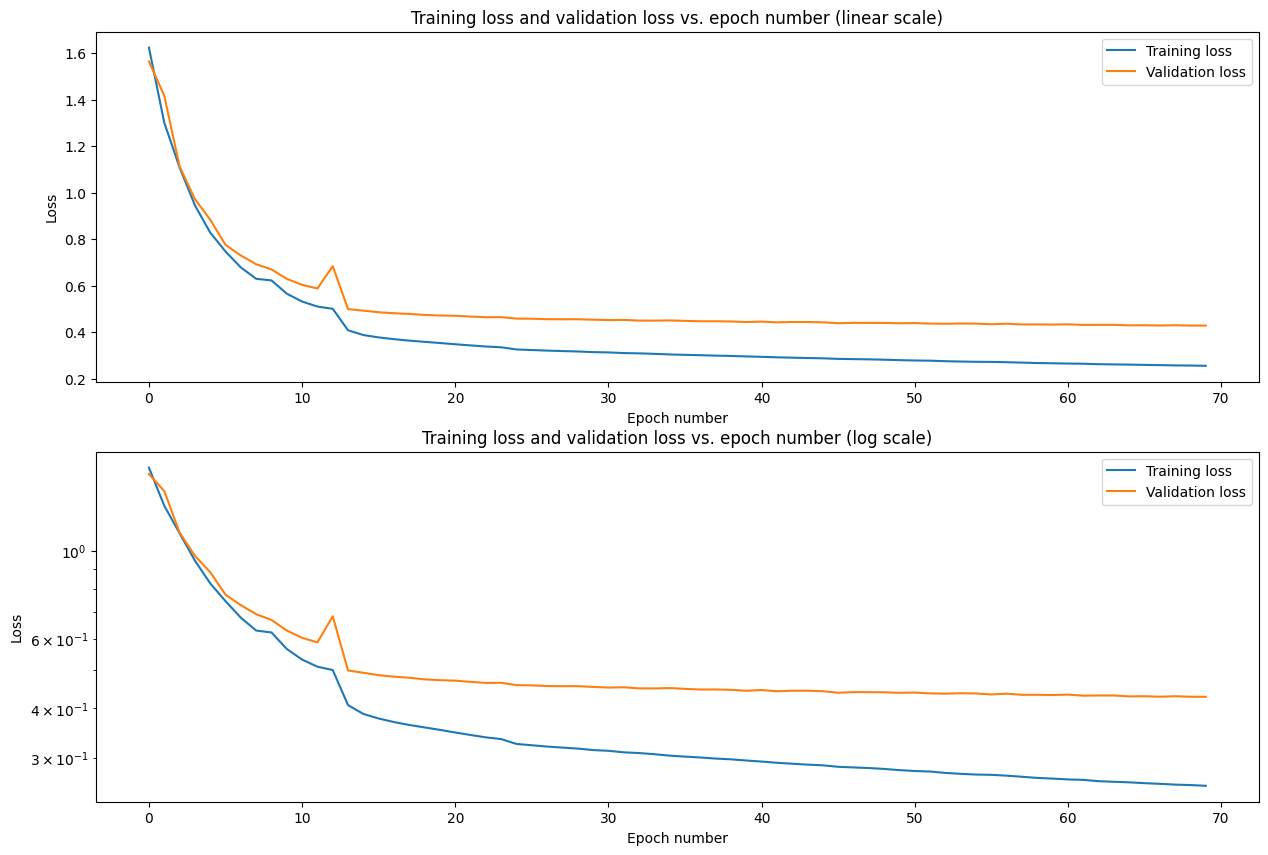

In [56]:
#@markdown ##Play the cell to show a plot of training errors vs. epoch number


lossDataFromCSV = []
vallossDataFromCSV = []

with open(os.path.join(QC_model_path,'Quality Control/training_evaluation.csv'),'r') as csvfile:
    csvRead = csv.reader(csvfile, delimiter=',')
    next(csvRead)
    for row in csvRead:
      if row:
        lossDataFromCSV.append(float(row[0]))
        vallossDataFromCSV.append(float(row[1]))

epochNumber = range(len(lossDataFromCSV))
plt.figure(figsize=(15,10))

plt.subplot(2,1,1)
plt.plot(epochNumber,lossDataFromCSV, label='Training loss')
plt.plot(epochNumber,vallossDataFromCSV, label='Validation loss')
plt.title('Training loss and validation loss vs. epoch number (linear scale)')
plt.ylabel('Loss')
plt.xlabel('Epoch number')
plt.legend()

plt.subplot(2,1,2)
plt.semilogy(epochNumber,lossDataFromCSV, label='Training loss')
plt.semilogy(epochNumber,vallossDataFromCSV, label='Validation loss')
plt.title('Training loss and validation loss vs. epoch number (log scale)')
plt.ylabel('Loss')
plt.xlabel('Epoch number')
plt.legend()
plt.savefig(os.path.join(QC_model_path,'Quality Control/lossCurvePlots.png'), bbox_inches='tight', pad_inches=0)
plt.show()



## **5.2. Error mapping and quality metrics estimation**
---

<font size = 4>This section will display SSIM maps and RSE maps as well as calculating total SSIM, NRMSE and PSNR metrics for all the images provided in the "QC_image_folder" using teh corresponding localization data contained in "QC_loc_folder" !

<font size = 4>**1. The SSIM (structural similarity) map**

<font size = 4>The SSIM metric is used to evaluate whether two images contain the same structures. It is a normalized metric and an SSIM of 1 indicates a perfect similarity between two images. Therefore for SSIM, the closer to 1, the better. The SSIM maps are constructed by calculating the SSIM metric in each pixel by considering the surrounding structural similarity in the neighbourhood of that pixel (currently defined as window of 11 pixels and with Gaussian weighting of 1.5 pixel standard deviation, see our Wiki for more info).

<font size=4>**mSSIM** is the SSIM value calculated across the entire window of both images.

<font size=4>**The output below shows the SSIM maps with the mSSIM**

<font size = 4>**2. The RSE (Root Squared Error) map**

<font size = 4>This is a display of the root of the squared difference between the normalized predicted and target or the source and the target. In this case, a smaller RSE is better. A perfect agreement between target and prediction will lead to an RSE map showing zeros everywhere (dark).


<font size =4>**NRMSE (normalised root mean squared error)** gives the average difference between all pixels in the images compared to each other. Good agreement yields low NRMSE scores.

<font size = 4>**PSNR (Peak signal-to-noise ratio)** is a metric that gives the difference between the ground truth and prediction (or source input) in decibels, using the peak pixel values of the prediction and the MSE between the images. The higher the score the better the agreement.

<font size=4>**The output below shows the RSE maps with the NRMSE and PSNR values.**





In [65]:

# ------------------------ User input ------------------------
#@markdown ##Choose the folders that contain your Quality Control dataset
QC_image_folder = "." #@param{type:"string"}
QC_loc_folder = "." #@param{type:"string"}
#@markdown Get pixel size from file?
get_pixel_size_from_file = True #@param {type:"boolean"}
#@markdown Otherwise, use this value:
pixel_size = 100 #@param {type:"number"}

if get_pixel_size_from_file:
  pixel_size_INPUT = None
else:
  pixel_size_INPUT = pixel_size


# ------------------------ QC analysis loop over provided dataset ------------------------

savePath = os.path.join(QC_model_path, 'Quality Control')

# Open and create the csv file that will contain all the QC metrics
with open(os.path.join(savePath, os.path.basename(QC_model_path)+"_QC_metrics.csv"), "w", newline='') as file:
  writer = csv.writer(file)

  # Write the header in the csv file
  writer.writerow(["image #","Prediction v. GT mSSIM","WF v. GT mSSIM", "Prediction v. GT NRMSE","WF v. GT NRMSE", "Prediction v. GT PSNR", "WF v. GT PSNR"])

  # These lists will be used to collect all the metrics values per slice
  file_name_list = []
  slice_number_list = []
  mSSIM_GvP_list = []
  mSSIM_GvWF_list = []
  NRMSE_GvP_list = []
  NRMSE_GvWF_list = []
  PSNR_GvP_list = []
  PSNR_GvWF_list = []

  # Let's loop through the provided dataset in the QC folders

  for (imageFilename, locFilename) in zip(list_files(QC_image_folder, 'tif'), list_files(QC_loc_folder, 'csv')):
    print('--------------')
    print(imageFilename)
    print(locFilename)

    # Get the prediction
    batchFramePredictionLocalization(QC_image_folder, imageFilename, QC_model_path, savePath, pixel_size = pixel_size_INPUT)

    # test_model(QC_image_folder, imageFilename, QC_model_path, savePath, display=False);
    thisPrediction = io.imread(os.path.join(savePath, 'Predicted_'+imageFilename))
    thisWidefield = io.imread(os.path.join(savePath, 'Widefield_'+imageFilename))

    Mhr = thisPrediction.shape[0]
    Nhr = thisPrediction.shape[1]

    if pixel_size_INPUT == None:
      pixel_size, N, M = getPixelSizeTIFFmetadata(os.path.join(QC_image_folder,imageFilename))

    upsampling_factor = int(Mhr/M)
    print('Upsampling factor: '+str(upsampling_factor))
    pixel_size_hr = pixel_size/upsampling_factor # in nm

    # Load the localization file and display the first
    LocData = pd.read_csv(os.path.join(QC_loc_folder,locFilename), index_col=0)

    x = np.array(list(LocData['x [nm]']))
    y = np.array(list(LocData['y [nm]']))
    locImage = FromLoc2Image_SimpleHistogram(x, y, image_size = (Mhr,Nhr), pixel_size = pixel_size_hr)

    # Remove extension from filename
    imageFilename_no_extension = os.path.splitext(imageFilename)[0]

    # io.imsave(os.path.join(savePath, 'GT_image_'+imageFilename), locImage)
    saveAsTIF(savePath, 'GT_image_'+imageFilename_no_extension, locImage, pixel_size_hr)

    # Normalize the images wrt each other by minimizing the MSE between GT and prediction
    test_GT_norm, test_prediction_norm = norm_minmse(locImage, thisPrediction, normalize_gt=True)
    # Normalize the images wrt each other by minimizing the MSE between GT and Source image
    test_GT_norm, test_wf_norm = norm_minmse(locImage, thisWidefield, normalize_gt=True)

    # -------------------------------- Calculate the metric maps and save them --------------------------------

    # Calculate the SSIM maps
    index_SSIM_GTvsPrediction, img_SSIM_GTvsPrediction = structural_similarity(test_GT_norm, test_prediction_norm, data_range=1., full=True)
    index_SSIM_GTvsWF, img_SSIM_GTvsWF = structural_similarity(test_GT_norm, test_wf_norm, data_range=1., full=True)


    # Save ssim_maps
    img_SSIM_GTvsPrediction_32bit = np.float32(img_SSIM_GTvsPrediction)
    # io.imsave(os.path.join(savePath,'SSIM_GTvsPrediction_'+imageFilename),img_SSIM_GTvsPrediction_32bit)
    saveAsTIF(savePath,'SSIM_GTvsPrediction_'+imageFilename_no_extension, img_SSIM_GTvsPrediction_32bit, pixel_size_hr)


    img_SSIM_GTvsWF_32bit = np.float32(img_SSIM_GTvsWF)
    # io.imsave(os.path.join(savePath,'SSIM_GTvsWF_'+imageFilename),img_SSIM_GTvsWF_32bit)
    saveAsTIF(savePath,'SSIM_GTvsWF_'+imageFilename_no_extension, img_SSIM_GTvsWF_32bit, pixel_size_hr)


    # Calculate the Root Squared Error (RSE) maps
    img_RSE_GTvsPrediction = np.sqrt(np.square(test_GT_norm - test_prediction_norm))
    img_RSE_GTvsWF = np.sqrt(np.square(test_GT_norm - test_wf_norm))

    # Save SE maps
    img_RSE_GTvsPrediction_32bit = np.float32(img_RSE_GTvsPrediction)
    # io.imsave(os.path.join(savePath,'RSE_GTvsPrediction_'+imageFilename),img_RSE_GTvsPrediction_32bit)
    saveAsTIF(savePath,'RSE_GTvsPrediction_'+imageFilename_no_extension, img_RSE_GTvsPrediction_32bit, pixel_size_hr)

    img_RSE_GTvsWF_32bit = np.float32(img_RSE_GTvsWF)
    # io.imsave(os.path.join(savePath,'RSE_GTvsWF_'+imageFilename),img_RSE_GTvsWF_32bit)
    saveAsTIF(savePath,'RSE_GTvsWF_'+imageFilename_no_extension, img_RSE_GTvsWF_32bit, pixel_size_hr)


    # -------------------------------- Calculate the RSE metrics and save them --------------------------------

    # Normalised Root Mean Squared Error (here it's valid to take the mean of the image)
    NRMSE_GTvsPrediction = np.sqrt(np.mean(img_RSE_GTvsPrediction))
    NRMSE_GTvsWF = np.sqrt(np.mean(img_RSE_GTvsWF))

    # We can also measure the peak signal to noise ratio between the images
    PSNR_GTvsPrediction = psnr(test_GT_norm,test_prediction_norm,data_range=1.0)
    PSNR_GTvsWF = psnr(test_GT_norm,test_wf_norm,data_range=1.0)

    writer.writerow([imageFilename,str(index_SSIM_GTvsPrediction),str(index_SSIM_GTvsWF),str(NRMSE_GTvsPrediction),str(NRMSE_GTvsWF),str(PSNR_GTvsPrediction), str(PSNR_GTvsWF)])

    # Collect values to display in dataframe output
    file_name_list.append(imageFilename)
    mSSIM_GvP_list.append(index_SSIM_GTvsPrediction)
    mSSIM_GvWF_list.append(index_SSIM_GTvsWF)
    NRMSE_GvP_list.append(NRMSE_GTvsPrediction)
    NRMSE_GvWF_list.append(NRMSE_GTvsWF)
    PSNR_GvP_list.append(PSNR_GTvsPrediction)
    PSNR_GvWF_list.append(PSNR_GTvsWF)


# Table with metrics as dataframe output
pdResults = pd.DataFrame(index = file_name_list)
pdResults["Prediction v. GT mSSIM"] = mSSIM_GvP_list
pdResults["Wide-field v. GT mSSIM"] = mSSIM_GvWF_list
pdResults["Prediction v. GT NRMSE"] = NRMSE_GvP_list
pdResults["Wide-field v. GT NRMSE"] = NRMSE_GvWF_list
pdResults["Prediction v. GT PSNR"] = PSNR_GvP_list
pdResults["Wide-field v. GT PSNR"] = PSNR_GvWF_list


# ------------------------ Display ------------------------

print('--------------------------------------------')
@interact


def show_QC_results(files = list_files(QC_image_folder, 'tif')):
    plt.figure(figsize=(15,15))
    # Target (Ground-truth)
    plt.subplot(3,3,1)
    plt.axis('off')
    img_GT = io.imread(os.path.join(savePath, 'GT_image_'+file))
    plt.imshow(img_GT, norm = simple_norm(img_GT, percent = 99.5))
    plt.title('Target',fontsize=15)

    # Wide-field
    plt.subplot(3,3,2)
    plt.axis('off')
    img_Source = io.imread(os.path.join(savePath, 'Widefield_'+file))
    plt.imshow(img_Source, norm = simple_norm(img_Source, percent = 99.5))
    plt.title('Widefield',fontsize=15)

    #Prediction
    plt.subplot(3,3,3)
    plt.axis('off')
    img_Prediction = io.imread(os.path.join(savePath, 'Predicted_'+file))
    plt.imshow(img_Prediction, norm = simple_norm(img_Prediction, percent = 99.5))
    plt.title('Prediction',fontsize=15)

    #Setting up colours
    cmap = plt.cm.CMRmap

    #SSIM between GT and Source
    plt.subplot(3,3,5)
    #plt.axis('off')
    plt.tick_params(
        axis='both',      # changes apply to the x-axis and y-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,        # ticks along the top edge are off
        left=False,       # ticks along the left edge are off
        right=False,         # ticks along the right edge are off
        labelbottom=False,
        labelleft=False)
    img_SSIM_GTvsWF = io.imread(os.path.join(savePath, 'SSIM_GTvsWF_'+file))
    imSSIM_GTvsWF = plt.imshow(img_SSIM_GTvsWF, cmap = cmap, vmin=0, vmax=1)
    plt.colorbar(imSSIM_GTvsWF,fraction=0.046, pad=0.04)
    plt.title('Target vs. Widefield',fontsize=15)
    plt.xlabel('mSSIM: '+str(round(pdResults.loc[file]["Wide-field v. GT mSSIM"],3)),fontsize=14)
    plt.ylabel('SSIM maps',fontsize=20, rotation=0, labelpad=75)

    #SSIM between GT and Prediction
    plt.subplot(3,3,6)
    #plt.axis('off')
    plt.tick_params(
        axis='both',      # changes apply to the x-axis and y-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,        # ticks along the top edge are off
        left=False,       # ticks along the left edge are off
        right=False,         # ticks along the right edge are off
        labelbottom=False,
        labelleft=False)
    img_SSIM_GTvsPrediction = io.imread(os.path.join(savePath, 'SSIM_GTvsPrediction_'+file))
    imSSIM_GTvsPrediction = plt.imshow(img_SSIM_GTvsPrediction, cmap = cmap, vmin=0,vmax=1)
    plt.colorbar(imSSIM_GTvsPrediction,fraction=0.046, pad=0.04)
    plt.title('Target vs. Prediction',fontsize=15)
    plt.xlabel('mSSIM: '+str(round(pdResults.loc[file]["Prediction v. GT mSSIM"],3)),fontsize=14)

    #Root Squared Error between GT and Source
    plt.subplot(3,3,8)
    #plt.axis('off')
    plt.tick_params(
        axis='both',      # changes apply to the x-axis and y-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,        # ticks along the top edge are off
        left=False,       # ticks along the left edge are off
        right=False,         # ticks along the right edge are off
        labelbottom=False,
        labelleft=False)
    img_RSE_GTvsWF = io.imread(os.path.join(savePath, 'RSE_GTvsWF_'+file))
    imRSE_GTvsWF = plt.imshow(img_RSE_GTvsWF, cmap = cmap, vmin=0, vmax = 1)
    plt.colorbar(imRSE_GTvsWF,fraction=0.046,pad=0.04)
    plt.title('Target vs. Widefield',fontsize=15)
    plt.xlabel('NRMSE: '+str(round(pdResults.loc[file]["Wide-field v. GT NRMSE"],3))+', PSNR: '+str(round(pdResults.loc[file]["Wide-field v. GT PSNR"],3)),fontsize=14)
    plt.ylabel('RSE maps',fontsize=20, rotation=0, labelpad=75)

    #Root Squared Error between GT and Prediction
    plt.subplot(3,3,9)
    #plt.axis('off')
    plt.tick_params(
        axis='both',      # changes apply to the x-axis and y-axis
        which='both',      # both major and minor ticks are affected
        bottom=False,      # ticks along the bottom edge are off
        top=False,        # ticks along the top edge are off
        left=False,       # ticks along the left edge are off
        right=False,         # ticks along the right edge are off
        labelbottom=False,
        labelleft=False)
    img_RSE_GTvsPrediction = io.imread(os.path.join(savePath, 'RSE_GTvsPrediction_'+file))
    imRSE_GTvsPrediction = plt.imshow(img_RSE_GTvsPrediction, cmap = cmap, vmin=0, vmax=1)
    plt.colorbar(imRSE_GTvsPrediction,fraction=0.046,pad=0.04)
    plt.title('Target vs. Prediction',fontsize=15)
    plt.xlabel('NRMSE: '+str(round(pdResults.loc[file]["Prediction v. GT NRMSE"],3))+', PSNR: '+str(round(pdResults.loc[file]["Prediction v. GT PSNR"],3)),fontsize=14)
    plt.savefig(QC_model_path+'/Quality Control/QC_example_data.png', bbox_inches='tight', pad_inches=0)
print('--------------------------------------------')
pdResults.head()


--------------------------------------------


interactive(children=(Dropdown(description='files', options=(), value=None), Output()), _dom_classes=('widget-…

--------------------------------------------


,Prediction v. GT mSSIM,Wide-field v. GT mSSIM,Prediction v. GT NRMSE,Wide-field v. GT NRMSE,Prediction v. GT PSNR,Wide-field v. GT PSNR


In [ ]:

# ------------------------------- User input -------------------------------
#@markdown ### Data parameters
Data_folder = "" #@param {type:"string"}
Result_folder = "" #@param {type:"string"}
#@markdown Get pixel size from file?
get_pixel_size_from_file = True #@param {type:"boolean"}
#@markdown Otherwise, use this value (in nm):
pixel_size = 100 #@param {type:"number"}

#@markdown ### Model parameters
#@markdown Do you want to use the model you just trained?
Use_the_current_trained_model = True #@param {type:"boolean"}
#@markdown Otherwise, please provide path to the model folder below
prediction_model_path = "" #@param {type:"string"}

#@markdown ### Prediction parameters
batch_size =  4#@param {type:"integer"}

#@markdown ### Post processing parameters
threshold =  0.1#@param {type:"number"}
neighborhood_size =  3#@param {type:"integer"}
#@markdown Do you want to locally average the model output with CoG estimator ?
use_local_average = True #@param {type:"boolean"}


if get_pixel_size_from_file:
  pixel_size = None

if (Use_the_current_trained_model):
  prediction_model_path = os.path.join(model_path, model_name)

if os.path.exists(prediction_model_path):
  print("The "+os.path.basename(prediction_model_path)+" model will be used.")
else:
  print(bcolors.WARNING+'!! WARNING: The chosen model does not exist !!'+bcolors.NORMAL)
  print('Please make sure you provide a valid model path before proceeding further.')

# inform user whether local averaging is being used
if use_local_average == True:
  print('Using local averaging')

if not os.path.exists(Result_folder):
  print('Result folder was created.')
  os.makedirs(Result_folder)


# ------------------------------- Run predictions -------------------------------

start = time.time()
#%% This script tests the trained fully convolutional network based on the
# saved training weights, and normalization created using train_model.

if os.path.isdir(Data_folder):
  for filename in list_files(Data_folder, 'tif'):
    # run the testing/reconstruction process
    print("------------------------------------")
    print("Running prediction on: "+ filename)
    batchFramePredictionLocalization(Data_folder, filename, prediction_model_path, Result_folder,
                                     batch_size,
                                     threshold,
                                     neighborhood_size,
                                     use_local_average,
                                     pixel_size = pixel_size)

elif os.path.isfile(Data_folder):
  batchFramePredictionLocalization(os.path.dirname(Data_folder), os.path.basename(Data_folder), prediction_model_path, Result_folder,
                                   batch_size,
                                   threshold,
                                   neighborhood_size,
                                   use_local_average,
                                   pixel_size = pixel_size)



print('--------------------------------------------------------------------')
# Displaying the time elapsed for training
dt = time.time() - start
minutes, seconds = divmod(dt, 60)
hours, minutes = divmod(minutes, 60)
print("Time elapsed:",hours, "hour(s)",minutes,"min(s)",round(seconds),"sec(s)")


# ------------------------------- Interactive display -------------------------------

print('--------------------------------------------------------------------')
print('---------------------------- Previews ------------------------------')
print('--------------------------------------------------------------------')

if os.path.isdir(Data_folder):
  @interact
  def show_QC_results(file = list_files(Data_folder, 'tif')):

    plt.figure(figsize=(15,7.5))
    # Wide-field
    plt.subplot(1,2,1)
    plt.axis('off')
    img_Source = io.imread(os.path.join(Result_folder, 'Widefield_'+file))
    plt.imshow(img_Source, norm = simple_norm(img_Source, percent = 99.5))
    plt.title('Widefield', fontsize=15)
    # Prediction
    plt.subplot(1,2,2)
    plt.axis('off')
    img_Prediction = io.imread(os.path.join(Result_folder, 'Predicted_'+file))
    plt.imshow(img_Prediction, norm = simple_norm(img_Prediction, percent = 99.5))
    plt.title('Predicted',fontsize=15)

if os.path.isfile(Data_folder):

  plt.figure(figsize=(15,7.5))
  # Wide-field
  plt.subplot(1,2,1)
  plt.axis('off')
  img_Source = io.imread(os.path.join(Result_folder, 'Widefield_'+os.path.basename(Data_folder)))
  plt.imshow(img_Source, norm = simple_norm(img_Source, percent = 99.5))
  plt.title('Widefield', fontsize=15)
  # Prediction
  plt.subplot(1,2,2)
  plt.axis('off')
  img_Prediction = io.imread(os.path.join(Result_folder, 'Predicted_'+os.path.basename(Data_folder)))
  plt.imshow(img_Prediction, norm = simple_norm(img_Prediction, percent = 99.5))
  plt.title('Predicted',fontsize=15)

